<a href="https://colab.research.google.com/github/Ashima010302/self-pruning-neural-network/blob/main/Tredence_assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
!pip install torch torchvision matplotlib -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [79]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) * 0.1 - 1)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores)

In [80]:
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_all_gates(self):
        return [
            self.fc1.get_gates(),
            self.fc2.get_gates(),
            self.fc3.get_gates()
        ]

In [81]:
def sparsity_loss(model):
    loss = 0
    for gates in model.get_all_gates():
        loss += torch.mean(gates)*10
    return loss

In [82]:
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=128, shuffle=False)

In [83]:
def train_model(lambda_val, epochs=10):
    model = PrunableNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            cls_loss = criterion(outputs, labels)
            sp_loss = sparsity_loss(model)

            if epoch < 3:
               loss = cls_loss
            else:
              loss = cls_loss + lambda_val * sp_loss


            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    return model

In [84]:
def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [85]:
def calculate_sparsity(model, threshold=0.05 ):
    total = 0
    pruned = 0

    for gates in model.get_all_gates():
        total += gates.numel()
        pruned += (gates < threshold).sum().item()

    return 100 * pruned / total

In [86]:
lambdas = [0.01, 0.05, 0.1]
results = []
models = []

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")

    model = train_model(lam, epochs=10)

    acc = evaluate(model)
    sparsity = calculate_sparsity(model)

    print(f"Accuracy: {acc:.2f}%, Sparsity: {sparsity:.2f}%")

    results.append((lam, acc, sparsity))
    models.append(model)


Training with lambda = 0.01
Epoch 1, Loss: 794.9439
Epoch 2, Loss: 731.2160
Epoch 3, Loss: 689.6905
Epoch 4, Loss: 686.0001
Epoch 5, Loss: 658.5524
Epoch 6, Loss: 636.1696
Epoch 7, Loss: 615.6574
Epoch 8, Loss: 601.0934
Epoch 9, Loss: 586.6214
Epoch 10, Loss: 574.0090
Accuracy: 47.42%, Sparsity: 6.30%

Training with lambda = 0.05
Epoch 1, Loss: 798.5985
Epoch 2, Loss: 731.3420
Epoch 3, Loss: 690.6344
Epoch 4, Loss: 786.9186
Epoch 5, Loss: 739.9147
Epoch 6, Loss: 707.7515
Epoch 7, Loss: 686.1599
Epoch 8, Loss: 666.0213
Epoch 9, Loss: 647.7569
Epoch 10, Loss: 634.0999
Accuracy: 47.82%, Sparsity: 57.96%

Training with lambda = 0.1
Epoch 1, Loss: 798.5801
Epoch 2, Loss: 729.8717
Epoch 3, Loss: 693.7277
Epoch 4, Loss: 915.0087
Epoch 5, Loss: 833.7237
Epoch 6, Loss: 786.9989
Epoch 7, Loss: 753.2516
Epoch 8, Loss: 726.4748
Epoch 9, Loss: 704.9658
Epoch 10, Loss: 686.3780
Accuracy: 47.94%, Sparsity: 60.78%


In [87]:
print("\nFinal Results:")
print("Lambda | Accuracy | Sparsity")

for lam, acc, sp in results:
    print(f"{lam} | {acc:.2f}% | {sp:.2f}%")


Final Results:
Lambda | Accuracy | Sparsity
0.01 | 47.42% | 6.30%
0.05 | 47.82% | 57.96%
0.1 | 47.94% | 60.78%


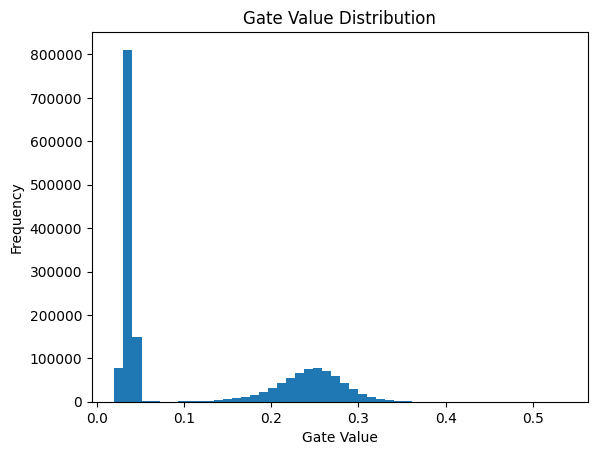

In [88]:
def plot_gates(model):
    all_gates = []

    for gates in model.get_all_gates():
        all_gates.extend(gates.detach().cpu().numpy().flatten())

    plt.figure()
    plt.hist(all_gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Value")
    plt.ylabel("Frequency")
    plt.show()


plot_gates(models[-1])